# Federated Deep Learning for Financial Fraud Detection using TensorFlow

This notebook demonstrates how to implement federated learning for financial fraud detection using NVIDIA FLARE (NVFlare). The notebook shows a complete workflow for training a deep learning model across multiple clients while maintaining data privacy.

## 0. Define User Info
Update the user information based on your details and the MLFlow server provided.

In [1]:
#startup_kit_location = "/path/to/admin_startup_kit"
startup_kit_location = "/home/hroth/Code/finance_poc/admin"
username = "admin@nvidia.com"

# MLFlow tracking info
mlflow_tracking_uri = "https://rrayrz6j-nvflmlflowserver.xenon.lepton.run"

## 1. Define Recipe

By default, we can use a small randomly generated dataset to illustrate the workflow. If the full sythentic dataset should be used, please provide the filepath with the `--dataset` train argument.

In [2]:
from src.pt.model import SimpleNetwork

from nvflare.app_opt.pt.recipes.fedavg import FedAvgRecipe
from nvflare.recipe.sim_env import SimEnv
from nvflare.recipe.prod_env import ProdEnv

num_rounds = 5

recipe = FedAvgRecipe(
    name="hello-pt-mlflow",
    min_clients=1,
    num_rounds=num_rounds,
    initial_model=SimpleNetwork(num_classes=2),
    train_script="src/pt/client.py",
    train_args="--data_path /workspace/dataset/synthetic1" # assumes each client uses the same directory path; `None` uses randomly generated data
)

2025-09-18 10:41:48.664009: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-18 10:41:48.706606: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-18 10:41:49.535896: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Add Experiment Tracking
We can add a central MLFlow tracker where clients can report their training progress.

In [3]:
from nvflare.recipe.utils import add_experiment_tracking

add_experiment_tracking(recipe, tracking_type="mlflow", tracking_config={"tracking_uri": mlflow_tracking_uri})

### Add filter to collect SHAP metrics on the server
We add a filter to the server to collect the incoming SHAP metrics reported by the clients.

In [4]:
from src.pt.utils import ShapCollectionFilter
shap_filter = ShapCollectionFilter()
recipe.add_server_input_filter(shap_filter, tasks=["train"])

# optionally export
recipe.export("job_configs")

## 2. (Optionally) Run in Simulation Environment

In [5]:
#env = SimEnv(num_clients=1)
#recipe.execute(env=env)

## 3. Run in Production Environment

In [6]:
env = ProdEnv(startup_kit_location=startup_kit_location, username=username)
run = recipe.execute(env=env)

Connecting to FLARE ...
Submitted job 'hello-pt-mlflow' with ID: ba44266c-72ed-4619-9ed0-011ca2d71bd1


### Get Status

In [7]:
print("Job Status is:", run.get_status())

Connecting to FLARE ...
Job Status is: RUNNING


### Get Results

In [8]:
result_path = run.get_result()
print("Result can be found in:", result_path)

Connecting to FLARE ...
Job ID:  ba44266c-72ed-4619-9ed0-011ca2d71bd1
Job Meta:  {'name': 'hello-pt-mlflow', 'resource_spec': {}, 'min_clients': 1, 'deploy_map': {'app': ['@ALL']}, 'byoc': True, 'submitter_name': 'admin@nvidia.com', 'submitter_org': 'nvidia', 'submitter_role': 'project_admin', 'job_folder_name': 'hello-pt-mlflow', 'job_id': 'ba44266c-72ed-4619-9ed0-011ca2d71bd1', 'submit_time': 1758206514.0283267, 'submit_time_iso': '2025-09-18T14:41:54.028327+00:00', 'start_time': '2025-09-18 14:41:56.890647', 'duration': 'N/A', 'data_storage_format': 2, 'status': 'RUNNING', 'job_deploy_detail': ['server: OK', 'site5: OK'], 'schedule_count': 1, 'last_schedule_time': 1758206515.2251537, 'schedule_history': ['2025-09-18 14:41:55: scheduled']}
..................
{'name': 'hello-pt-mlflow', 'resource_spec': {}, 'min_clients': 1, 'deploy_map': {'app': ['@ALL']}, 'byoc': True, 'submitter_name': 'admin@nvidia.com', 'submitter_org': 'nvidia', 'submitter_role': 'project_admin', 'job_folder_nam

### Visualization of Training Progress

In the meantime, you can check the progress via mlflow: [https://rrayrz6j-nvflmlflowserver.xenon.lepton.run](https://rrayrz6j-nvflmlflowserver.xenon.lepton.run)

The mflow metrics should show the accuracy progressing at each round:

![mlflow model metrics](./figs/mlflow.png)

### Optionally Abort Job
If you'd like to stop the job before completion for any reason, you can run:

In [9]:
#run.abort()

### 4. Visualize SHAP metrics
In this example, the server collects the clients' SHAP metrics at each round and saves them to a file. After downloading the training artifacts from the server (using `run.get_result()`), we can access them here and plot the results.

In [10]:
shap_metrics_file = result_path + "/workspace/app_server/shap_values.npy"
client = "site5"
num_round = num_rounds - 1

import matplotlib.pyplot as plt
%matplotlib inline

from src.pt.utils import plot_attribution_summary, plot_attribution_feature_importance, load_shap_metrics

all_shap_metrics = load_shap_metrics(shap_metrics_file)
print(f"All SHAP metrics: {all_shap_metrics.keys()}")

shap_metrics = all_shap_metrics[f"round{num_round}"][client]
print(f"SHAP metrics for round {num_round} and site-1: {shap_metrics.keys()}")   

All SHAP metrics: dict_keys(['round0', 'round1', 'round2', 'round3', 'round4'])
SHAP metrics for round 4 and site-1: dict_keys(['attributions', 'sample_features', 'feature_names', 'feature_importance', 'total_importance', 'samples_used', 'shap_values', 'shap_sample_features', 'shap_feature_names', 'shap_feature_importance', 'shap_total_importance', 'shap_samples_used'])


#### Show summary plot

<Figure size 500x400 with 0 Axes>

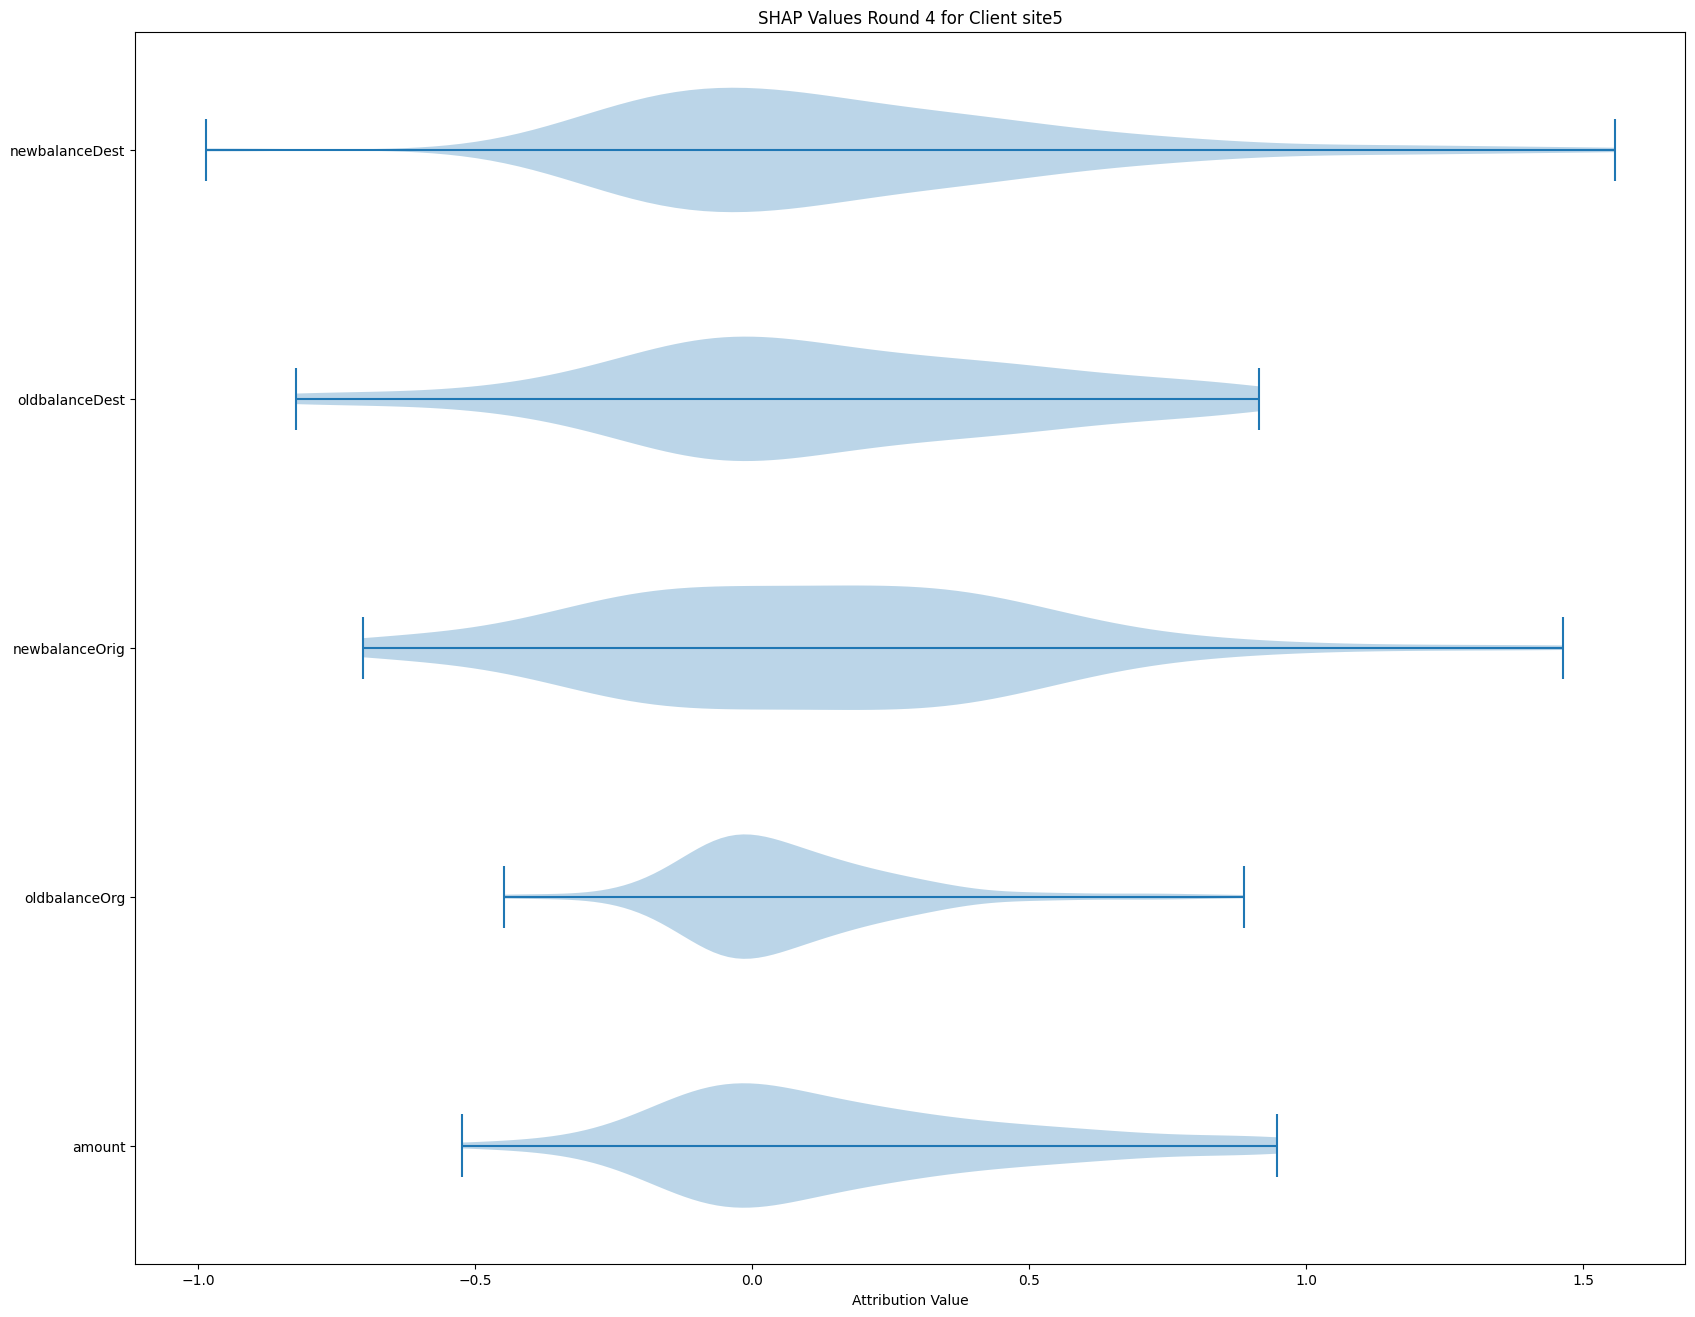

In [11]:
plot_attribution_summary(shap_metrics)
plt.title(f"SHAP Values Round {num_round} for Client {client}")
plt.show()

#### Show feature importance plot

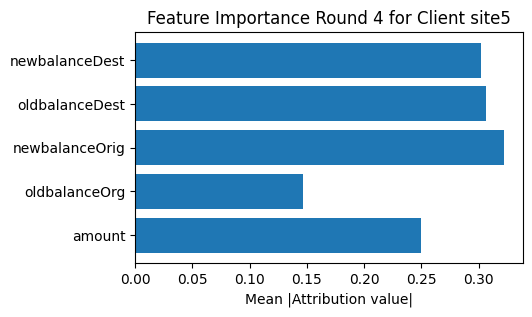

In [12]:
plot_attribution_feature_importance(shap_metrics)
plt.title(f"Feature Importance Round {num_round} for Client {client}")
plt.show()